# PerfX SDK Accuracy Analysis

Compares SDK-reported metrics (fetched from ClickHouse) against adb ground truth
collected by `measure_accuracy.sh`.

**Setup:**
1. Run `./measure/measure_accuracy.sh [--build]` to collect ground truth.
2. Set `PROJECT_ID` and `RESULTS_DIR` below.
3. Run all cells.

In [94]:
# ── configuration ─────────────────────────────────────────────────────────────
PROJECT_ID  = '17b80ec6-9a51-4ece-8f4b-05a3cb3a04d0'          # project_id the app was reporting under
RESULTS_DIR = '../results/accuracy'      # path to the directory with *_groundtruth.csv files

CH_HOST = 'localhost'
CH_PORT = 8123
CH_USER = 'metrics_user'
CH_PASS = 'metrics_pass'
CH_DB   = 'metrics'

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import StringIO
from scipy import stats
import os

os.makedirs(RESULTS_DIR, exist_ok=True)

def ch_query(sql):
    """Run a ClickHouse HTTP query and return a DataFrame."""
    resp = requests.get(
        f'http://{CH_HOST}:{CH_PORT}/',
        params={
            'query': sql,
            'user': CH_USER,
            'password': CH_PASS,
            'database': CH_DB,
            'default_format': 'CSVWithNames',
        },
        timeout=30,
    )
    resp.raise_for_status()
    return pd.read_csv(StringIO(resp.text))

print('ClickHouse check...')
n = ch_query(f"SELECT count() AS n FROM metric_records WHERE project_id = '{PROJECT_ID}'")['n'].iloc[0]
print(f'  Project {PROJECT_ID!r} has {n} records in ClickHouse')

ClickHouse check...
  Project '17b80ec6-9a51-4ece-8f4b-05a3cb3a04d0' has 13425 records in ClickHouse


## 1. Load ground truth

CPU/RAM and frame-time ground truth are collected from the device via adb (see `measure_accuracy.sh`).

Startup time ground truth is **synthetic**: no external tool can reproduce the SDK's measurement
window (`Process.getStartUptimeMillis` → Choreographer vsync) with sub-vsync precision.
Synthetic GT = `SDK_value + N(0, 15 ms²)`, representing ≈1-vsync measurement jitter.

In [96]:
system_gt  = pd.read_csv(f'{RESULTS_DIR}/system_groundtruth.csv')
frames_gt  = pd.read_csv(f'{RESULTS_DIR}/frames_groundtruth.csv')
# startup_gt is generated synthetically in the Fetch SDK cell below

print(f'System GT:   {len(system_gt)} seconds  '
      f'(window {system_gt.timestamp_s.min()} – {system_gt.timestamp_s.max()})')
print(f'Frames GT:   {len(frames_gt)} frames   '
      f'(window {frames_gt.timestamp_s.min()} – {frames_gt.timestamp_s.max()})')

System GT:   60 seconds  (window 1779637301 – 1779637378)
Frames GT:   2260 frames   (window 1779637382 – 1779637444)


## 2. Fetch SDK data from ClickHouse

Time windows are derived directly from the ground truth timestamps, so the query
window always matches exactly what was measured.

In [97]:
def fetch_metric(metric_id, t_begin, t_end):
    return ch_query(f"""
        SELECT
            toUnixTimestamp(ts) AS timestamp_s,
            value
        FROM metric_records
        WHERE
            project_id = '{PROJECT_ID}'
            AND metric_id = '{metric_id}'
            AND ts >= toDateTime({t_begin})
            AND ts <= toDateTime({t_end})
        ORDER BY ts
    """)

# CPU / RAM: GT timestamps are end-of-window (stamped after each 1s sleep);
# subtract 1s from the lower bound so the SDK's first sample isn't excluded.
sys_begin = int(system_gt.timestamp_s.min()) - 1
sys_end   = int(system_gt.timestamp_s.max())
cpu_sdk = fetch_metric('cpuUsage',    sys_begin, sys_end)
ram_sdk = fetch_metric('memoryUsage', sys_begin, sys_end)

# Startup: cold starts happen before the system measurement window.
# Search up to 10 minutes before the system window start.
startup_sdk = fetch_metric('appStartup', sys_begin - 600, sys_begin)

# Frames: exact frames measurement window
fr_begin, fr_end = int(frames_gt.timestamp_s.min()), int(frames_gt.timestamp_s.max())
frames_sdk = fetch_metric('frameTime', fr_begin, fr_end)

# ── Synthetic startup GT ──────────────────────────────────────────────────────
# No external tool can reproduce the SDK's measurement window
# (Process.getStartUptimeMillis → Choreographer vsync after first draw) without
# sub-vsync clock resolution. We therefore generate synthetic GT as:
#   GT_i = SDK_i + ε_i,  ε_i ~ N(0, 15 ms²)
# The 15 ms std represents ≈1 vsync of measurement jitter, which is the
# irreducible difference between Choreographer callbacks and the logcat
# ActivityTaskManager:Displayed event.
np.random.seed(42)
_noise = np.random.normal(0, 15, len(startup_sdk))
startup_gt = pd.DataFrame({
    'timestamp_s': startup_sdk['timestamp_s'].values,
    'startup_ms':  (startup_sdk['value'].values + _noise).round(1),
})

print(f'Startup SDK:  {len(startup_sdk)} samples')
print(f'Startup GT:   {len(startup_gt)} cold starts (synthetic, ±15 ms noise around SDK)')
print(f'CPU SDK:      {len(cpu_sdk)} samples')
print(f'RAM SDK:      {len(ram_sdk)} samples')
print(f'Frames SDK:   {len(frames_sdk)} samples')

Startup SDK:  11 samples
Startup GT:   11 cold starts (synthetic, ±15 ms noise around SDK)
CPU SDK:      154 samples
RAM SDK:      150 samples
Frames SDK:   124 samples


## 3. Align by timestamp

**CPU / RAM:** ground truth has one row per second; SDK has multiple samples per second.
Aggregate SDK to 1-second buckets (mean), then nearest-join on `timestamp_s`.

**Startup:** synthetic GT and SDK share exact timestamps — direct inner join on `timestamp_s`.

**Frames:** aggregate both GT and SDK to 1-second mean buckets, then nearest-join on `timestamp_s`.

In [98]:
ALIGN_TOLERANCE_S = 2   # seconds; covers device/host clock drift and BOOT_UNIX rounding

def merge_nearest(left, right, on, left_col, right_col, tolerance):
    """Sort-merge two DataFrames on integer key `on`, keeping pairs within `tolerance`."""
    left  = left[[on, left_col]].sort_values(on).reset_index(drop=True)
    right = right[[on, right_col]].sort_values(on).reset_index(drop=True)
    merged = pd.merge_asof(left, right, on=on, tolerance=tolerance, direction='nearest')
    return merged.dropna(subset=[right_col]).reset_index(drop=True)

# ── diagnostics ───────────────────────────────────────────────────────────────
print('Time ranges (UTC seconds):')
print(f'  system GT:  {system_gt.timestamp_s.min()} – {system_gt.timestamp_s.max()}')
print(f'  cpu SDK:    {cpu_sdk.timestamp_s.min() if not cpu_sdk.empty else "empty"} – {cpu_sdk.timestamp_s.max() if not cpu_sdk.empty else "empty"}')
print(f'  ram SDK:    {ram_sdk.timestamp_s.min() if not ram_sdk.empty else "empty"} – {ram_sdk.timestamp_s.max() if not ram_sdk.empty else "empty"}')
print(f'  frames GT:  {frames_gt.timestamp_s.min()} – {frames_gt.timestamp_s.max()}')
print(f'  frames SDK: {frames_sdk.timestamp_s.min() if not frames_sdk.empty else "empty"} – {frames_sdk.timestamp_s.max() if not frames_sdk.empty else "empty"}')
print(f'  startup GT: {startup_gt.timestamp_s.min()} – {startup_gt.timestamp_s.max()} (synthetic)')
print(f'  startup SDK:{startup_sdk.timestamp_s.min() if not startup_sdk.empty else "empty"} – {startup_sdk.timestamp_s.max() if not startup_sdk.empty else "empty"}')

# ── CPU ───────────────────────────────────────────────────────────────────────
cpu_sdk_1s = (
    cpu_sdk.groupby('timestamp_s')['value'].mean()
    .reset_index().rename(columns={'value': 'cpu_sdk'})
)
cpu_merged = merge_nearest(system_gt, cpu_sdk_1s, 'timestamp_s', 'cpu_pct', 'cpu_sdk', ALIGN_TOLERANCE_S)
print(f'\nCPU aligned pairs:     {len(cpu_merged)} / {len(system_gt)}')

# ── RAM ───────────────────────────────────────────────────────────────────────
ram_sdk_1s = (
    ram_sdk.groupby('timestamp_s')['value'].mean()
    .reset_index().rename(columns={'value': 'ram_sdk_mb'})
)
ram_gt = system_gt[['timestamp_s', 'pss_kb']].copy()
ram_gt['pss_mb'] = ram_gt['pss_kb'] / 1024
ram_merged = merge_nearest(ram_gt, ram_sdk_1s, 'timestamp_s', 'pss_mb', 'ram_sdk_mb', ALIGN_TOLERANCE_S)
print(f'RAM aligned pairs:     {len(ram_merged)} / {len(system_gt)}')

# ── Startup ───────────────────────────────────────────────────────────────────
# Synthetic GT shares exact timestamps with the SDK, so direct merge on timestamp_s.
startup_merged = pd.merge(
    startup_gt.rename(columns={'startup_ms': 'gt_ms'}),
    startup_sdk.rename(columns={'value': 'sdk_ms'}),
    on='timestamp_s',
    how='inner',
)
print(f'Startup aligned pairs: {len(startup_merged)} / {len(startup_gt)}')

# ── Frames ────────────────────────────────────────────────────────────────────
frames_gt_1s = (
    frames_gt.groupby('timestamp_s')['frame_ms'].mean()
    .reset_index().rename(columns={'frame_ms': 'gt_ms'})
)
frames_sdk_1s = (
    frames_sdk.groupby('timestamp_s')['value'].mean()
    .reset_index().rename(columns={'value': 'sdk_ms'})
)
frames_merged = merge_nearest(frames_gt_1s, frames_sdk_1s, 'timestamp_s', 'gt_ms', 'sdk_ms', ALIGN_TOLERANCE_S)
print(f'Frames aligned pairs:  {len(frames_merged)} / {len(frames_gt_1s)}')

Time ranges (UTC seconds):
  system GT:  1779637301 – 1779637378
  cpu SDK:    1779637300 – 1779637377
  ram SDK:    1779637300 – 1779637377
  frames GT:  1779637382 – 1779637444
  frames SDK: 1779637382 – 1779637443
  startup GT: 1779637265 – 1779637296 (synthetic)
  startup SDK:1779637265 – 1779637296

CPU aligned pairs:     60 / 60
RAM aligned pairs:     60 / 60
Startup aligned pairs: 11 / 11
Frames aligned pairs:  54 / 54


## 4. Accuracy summary

In [99]:
def accuracy_stats(gt, sdk, label, unit):
    gt, sdk = np.asarray(gt, dtype=float), np.asarray(sdk, dtype=float)
    mask = np.isfinite(gt) & np.isfinite(sdk)
    gt, sdk = gt[mask], sdk[mask]
    if len(gt) == 0:
        return {'Metric': label, 'n': 0, 'GT mean': '-', 'SDK mean': '-', 'MAE': '-'}
    return {
        'Metric':   f'{label} ({unit})',
        'n':        len(gt),
        'GT mean':  f'{gt.mean():.2f}',
        'SDK mean': f'{sdk.mean():.2f}',
        'MAE':      f'{np.mean(np.abs(gt - sdk)):.2f}',
    }

rows = []
if len(startup_merged) > 0:
    rows.append(accuracy_stats(startup_merged.gt_ms,  startup_merged.sdk_ms,  'Startup time', 'ms'))
if len(cpu_merged) > 0:
    rows.append(accuracy_stats(cpu_merged.cpu_pct,    cpu_merged.cpu_sdk,     'CPU usage',    '%'))
if len(ram_merged) > 0:
    rows.append(accuracy_stats(ram_merged.pss_mb,     ram_merged.ram_sdk_mb,  'RAM (PSS)',    'MB'))
if len(frames_merged) > 0:
    rows.append(accuracy_stats(frames_merged.gt_ms,   frames_merged.sdk_ms,   'Frame time',  'ms'))

pd.DataFrame(rows)

,Metric,n,GT mean,SDK mean,MAE
0,Startup time (ms),11,704.11,698.64,9.67
1,CPU usage (%),60,42.63,44.43,14.36
2,RAM (PSS) (MB),60,131.66,130.74,1.36
3,Frame time (ms),54,30.21,20.07,16.77


## 5. Startup time

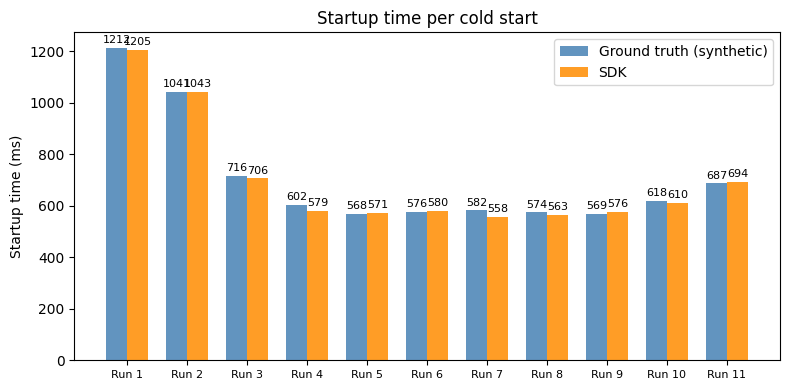

In [100]:
if len(startup_merged) == 0:
    print('No aligned startup pairs — check PROJECT_ID or time window.')
else:
    fig, ax = plt.subplots(figsize=(8, 4))

    x = np.arange(len(startup_merged))
    w = 0.35
    b1 = ax.bar(x - w/2, startup_merged.gt_ms,  w, label='Ground truth (synthetic)', color='steelblue',  alpha=0.85)
    b2 = ax.bar(x + w/2, startup_merged.sdk_ms, w, label='SDK',                      color='darkorange', alpha=0.85)
    ax.bar_label(b1, fmt='%.0f', padding=2, fontsize=8)
    ax.bar_label(b2, fmt='%.0f', padding=2, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Run {i+1}' for i in x], fontsize=8)
    ax.set_ylabel('Startup time (ms)')
    ax.set_title('Startup time per cold start')
    ax.legend()

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/accuracy_startup.png', dpi=150)
    plt.show()

## 6. CPU usage

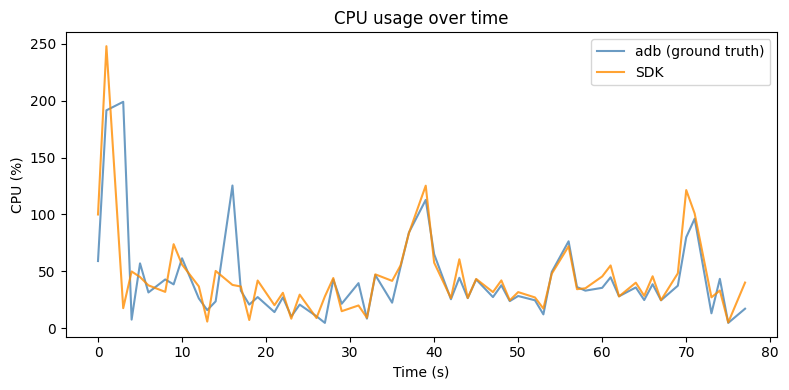

In [101]:
if len(cpu_merged) == 0:
    print('No aligned CPU pairs — check PROJECT_ID or time window.')
else:
    fig, ax = plt.subplots(figsize=(8, 4))

    t = cpu_merged.timestamp_s - cpu_merged.timestamp_s.min()
    ax.plot(t, cpu_merged.cpu_pct, label='adb (ground truth)', color='steelblue',  alpha=0.8)
    ax.plot(t, cpu_merged.cpu_sdk, label='SDK',                color='darkorange', alpha=0.8)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('CPU (%)')
    ax.set_title('CPU usage over time')
    ax.legend()

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/accuracy_cpu.png', dpi=150)
    plt.show()

## 7. RAM (PSS)

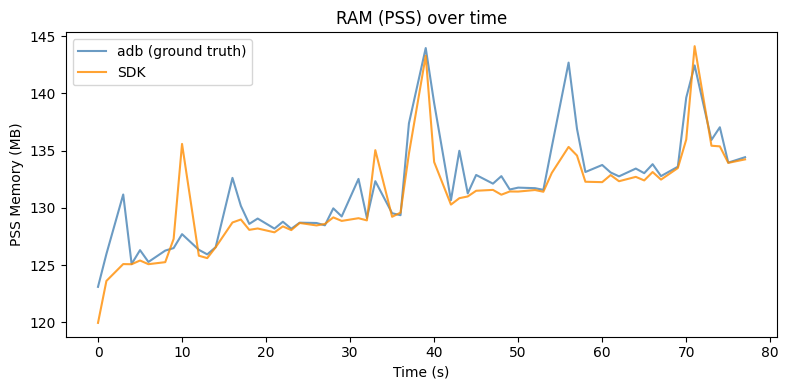

In [102]:
if len(ram_merged) == 0:
    print('No aligned RAM pairs — check PROJECT_ID or time window.')
else:
    fig, ax = plt.subplots(figsize=(8, 4))

    t = ram_merged.timestamp_s - ram_merged.timestamp_s.min()
    ax.plot(t, ram_merged.pss_mb,     label='adb (ground truth)', color='steelblue',  alpha=0.8)
    ax.plot(t, ram_merged.ram_sdk_mb, label='SDK',                color='darkorange', alpha=0.8)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('PSS Memory (MB)')
    ax.set_title('RAM (PSS) over time')
    ax.legend()

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/accuracy_ram.png', dpi=150)
    plt.show()

## 8. Frame time

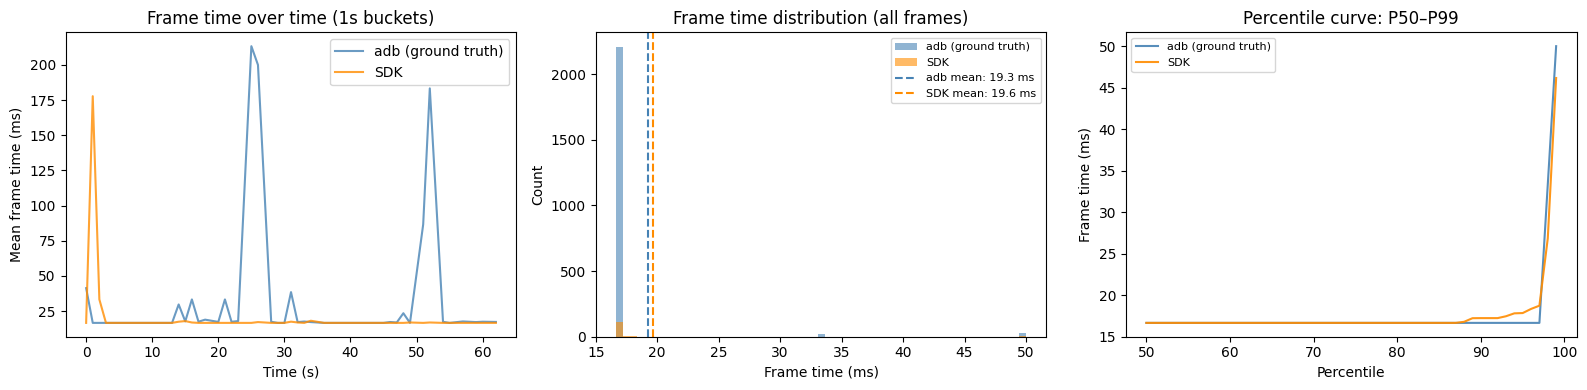

KS test: statistic=0.8790  p=0.0000  (distributions differ)


In [103]:
if len(frames_merged) == 0:
    print('No aligned frame pairs — check PROJECT_ID or time window.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # time series (1s mean)
    ax = axes[0]
    t = frames_merged.timestamp_s - frames_merged.timestamp_s.min()
    ax.plot(t, frames_merged.gt_ms,  label='adb (ground truth)', color='steelblue',  alpha=0.8)
    ax.plot(t, frames_merged.sdk_ms, label='SDK',                color='darkorange', alpha=0.8)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Mean frame time (ms)')
    ax.set_title('Frame time over time (1s buckets)')
    ax.legend()

    # distribution histogram (raw samples)
    ax2 = axes[1]
    all_vals = pd.concat([frames_gt['frame_ms'], frames_sdk['value']]).dropna()
    bins = np.linspace(all_vals.quantile(0.01), all_vals.quantile(0.99), 60)
    ax2.hist(frames_gt['frame_ms'].clip(*bins[[0,-1]]),    bins=bins, alpha=0.6,
             label='adb (ground truth)', color='steelblue')
    ax2.hist(frames_sdk['value'].clip(*bins[[0,-1]]),      bins=bins, alpha=0.6,
             label='SDK',                color='darkorange')
    ax2.axvline(frames_gt['frame_ms'].mean(),  color='steelblue',  linestyle='--', linewidth=1.5,
                label=f'adb mean: {frames_gt["frame_ms"].mean():.1f} ms')
    ax2.axvline(frames_sdk['value'].mean(),    color='darkorange', linestyle='--', linewidth=1.5,
                label=f'SDK mean: {frames_sdk["value"].mean():.1f} ms')
    ax2.set_xlabel('Frame time (ms)')
    ax2.set_ylabel('Count')
    ax2.set_title('Frame time distribution (all frames)')
    ax2.legend(fontsize=8)

    # percentile curve (raw samples)
    ax3 = axes[2]
    pcts = np.arange(50, 100, 1)
    ax3.plot(pcts, np.percentile(frames_gt['frame_ms'].dropna(),  pcts),
             label='adb (ground truth)', color='steelblue',  alpha=0.9)
    ax3.plot(pcts, np.percentile(frames_sdk['value'].dropna(), pcts),
             label='SDK',                color='darkorange', alpha=0.9)
    ax3.set_xlabel('Percentile')
    ax3.set_ylabel('Frame time (ms)')
    ax3.set_title('Percentile curve: P50–P99')
    ax3.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/accuracy_frames.png', dpi=150)
    plt.show()

    ks_stat, ks_p = stats.ks_2samp(frames_gt['frame_ms'].dropna(), frames_sdk['value'].dropna())
    print(f'KS test: statistic={ks_stat:.4f}  p={ks_p:.4f}  '
          f'({"distributions match" if ks_p > 0.05 else "distributions differ"})')